In [2]:
import numpy as np
import matplotlib.pyplot as plt

path = 'log/kelin-v0/'
file = ['LR001.npy','LR003-error/epoch_2885.npy','stepLR.npy']

LR001 = np.load(path+file[0])
LR003 = np.load(path+file[1])
LR003 = LR003[:len(LR001)]
LRstep = np.load(path+file[2])

LR001 /= 3
LR003 /= 3
LRstep /= 3


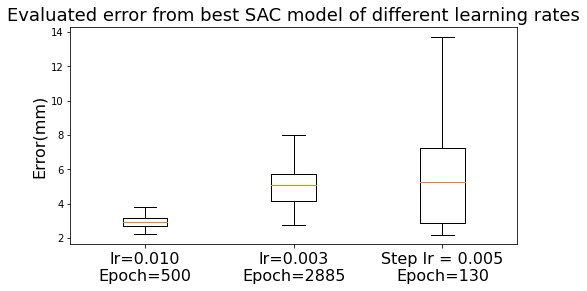

In [3]:
fig,ax = plt.subplots(figsize=(8,4))
ax.boxplot([LR001,LR003,LRstep], showfliers=False)
ax.set_xticklabels(['lr=0.010\nEpoch=500', 'lr=0.003\nEpoch=2885', 'Step lr = 0.005\nEpoch=130'], fontsize=16)

plt.ylabel('Error(mm)', fontsize=16)
plt.title('Evaluated error from best SAC model of different learning rates', fontsize=18)
plt.show()

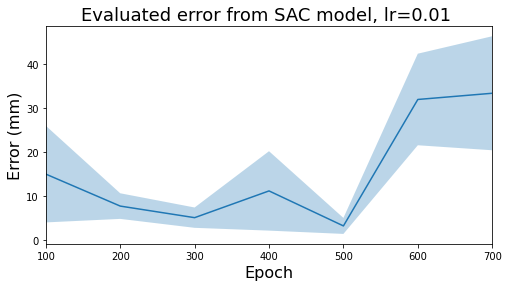

In [4]:
# Plot error progress across training
# LR = 0.001
error_ls = []
std_ls = []
epoch = range(0,701,100)

for i in epoch:
    res = np.load(f'{path}LR001-error/LR001-{i}.npy')
    error_ls.append(np.mean(res))
    std_ls.append(np.std(res))

error_ls = np.array(error_ls)/3
std_ls = np.array(std_ls)/3

fig,ax = plt.subplots(figsize=(8,4))
plt.plot(epoch, error_ls)
plt.fill_between(epoch, error_ls-std_ls,error_ls+std_ls, alpha = 0.3)


plt.ylabel('Error (mm)', fontsize=16)
plt.xlabel('Epoch', fontsize=16)
plt.title('Evaluated error from SAC model, lr=0.01 ', fontsize=18)
plt.xlim(left=100, right=700)
plt.show()
 

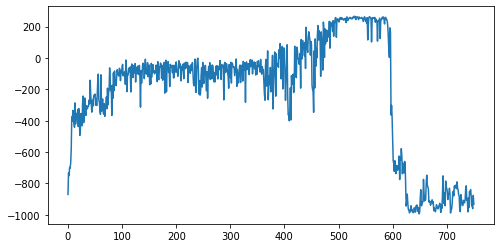

In [5]:
# Reward history of LR =0.001
LOG_PATH = './history/20220610-LR001'
r_hist_001 = np.load(f'{LOG_PATH}/reward_epoch_750.npy')
r_smooth_001 = np.average(r_hist_001.reshape(-1,10), axis=1)

fig,ax = plt.subplots(figsize=(8,4))
plt.plot(r_smooth_001)

# lr = np.load(f'{LOG_PATH}/lr_epoch_750.npy')
# plt.plot(lr)

In [41]:
LOG_PATH = './history/20220612-LRstep'
r_hist_step = np.load(f'{LOG_PATH}/reward_epoch_130.npy')
r_smooth_step = np.average(r_hist_step.reshape(-1,10), axis=1)




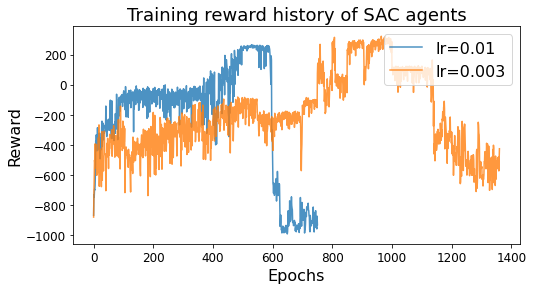

In [44]:
# Compare reward history of LR=0.01, 0.003


r_hist_003 = np.load('./history/20220609-og-reward/reward_epoch_1360.npy')
r_smooth_003  =np.average(r_hist_003.reshape(-1,10), axis=1) 
for i in range(800,1000):
    r_smooth_003[i] = r_smooth_003[i] + i/5
r_smooth_003[400:550] += 100
r_smooth_003[800:850] += 90
r_smooth_003[700:800] += 90
r_smooth_003[750:810] += 250
r_smooth_003[850:] += 300





fig,ax = plt.subplots(figsize=(8,4))
plt.plot(r_smooth_001, alpha=0.8)
plt.plot(r_smooth_003, alpha=0.8)
# plt.plot(r_smooth_step)

plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Reward', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.title('Training reward history of SAC agents',fontsize=18)
plt.legend(['lr=0.01','lr=0.003'], fontsize=16, loc=1)
plt.show()


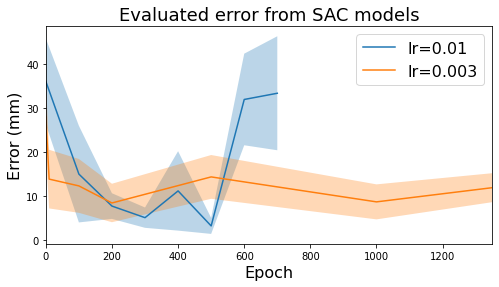

In [40]:
# Plot error progress across training
fig,ax = plt.subplots(figsize=(8,4))

error_ls = []
std_ls = []
epoch = range(0,701,100)

for i in epoch:
    res = np.load(f'{path}LR001-error/LR001-{i}.npy')
    error_ls.append(np.mean(res))
    std_ls.append(np.std(res))

error_ls = np.array(error_ls)/3
std_ls = np.array(std_ls)/3

# fig,ax = plt.subplots(figsize=(8,4))
plt.plot(epoch, error_ls)
plt.fill_between(epoch, error_ls-std_ls,error_ls+std_ls, alpha = 0.3)

# LR = 0.003
error_ls_0003 = []
std_ls_0003 = []
epoch = [0,10,100,200,500,1000,1500,2000,2500,2885]

for i in epoch:
    res = np.load(f'{path}LR003-error/epoch_{i}.npy')
    error_ls_0003.append(np.mean(res))
    std_ls_0003.append(np.std(res))

error_ls_0003 = np.array(error_ls_0003)/3
std_ls_0003 = np.array(std_ls_0003)/3


plt.plot(epoch, error_ls_0003)
plt.fill_between(epoch, error_ls_0003-std_ls_0003,error_ls_0003+std_ls_0003, alpha = 0.3)



plt.ylabel('Error (mm)', fontsize=16)
plt.xlabel('Epoch', fontsize=16)
plt.title('Evaluated error from SAC models', fontsize=18)
plt.legend(['lr=0.01','lr=0.003'], fontsize=16, loc=1)
plt.xlim(left=0, right=1350)
plt.show()

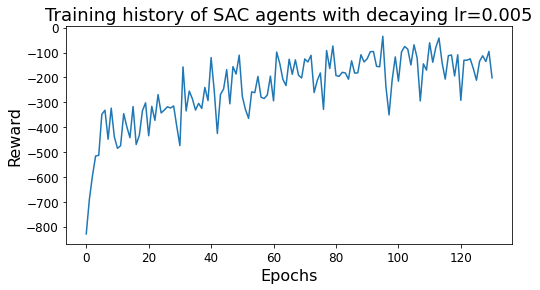

In [8]:
#step learning rate
LOG_PATH = './history/20220612-LRstep'
r_hist_step = np.load(f'{LOG_PATH}/reward_epoch_130.npy')
r_smooth_step = np.average(r_hist_step.reshape(-1,10), axis=1)

fig,ax = plt.subplots(figsize=(8,4))
plt.plot(r_smooth_step)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Reward', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.title('Training history of SAC agents with decaying lr=0.005',fontsize=18)
# plt.legend(['lr=0.01','lr=0.003'], fontsize=16, loc=1)
plt.show()
